
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E01_gradient_descent.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Gradient descent exercises

---
These are introductory exercises in Machine learning with focus in **gradient descent** .

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Simulate dataset (*)

Simulate datasets according to these rules:

- set random seed to 42
- (1000,2) samples from $X \sim \mathcal{U}(0,1)$ , i.e. 1000 rows, 2 columns. 
- 1000 samples from $\epsilon \sim \mathcal{N}(0,1)$
- $y = 3x_1 + 5x_2 + 3 + \epsilon$ , where $x_i$ is column $i$ of $X$

Finally add a column of ones for the intercept to $X$.

<details>

<summary>Hint</summary>

Use for simulating X

´´´
np.random.rand(samples, 2)
´´´

to concatenate with ones, use ```np.c_[..., ...]```

</details>

<details>

<summary>Answer</summary>

```
array([[1.        , 0.37454012, 0.95071431],
       [1.        , 0.73199394, 0.59865848],
       [1.        , 0.15601864, 0.15599452],
       [1.        , 0.05808361, 0.86617615],
       [1.        , 0.60111501, 0.70807258]])

```

</details>

---

In [1]:
import numpy as np

np.random.seed(42)

samples = 1000
X = np.random.rand(samples, 2)

epsilon = np.random.normal(loc=0, scale=1, size=samples)

x1 = X[:, 0]
x2 = X[:, 1]
y = 3*x1 + 5*x2 + 3 + epsilon

X = np.c_[np.ones(samples), X]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 3)
y shape: (1000,)


In [2]:
print(X)

[[1.         0.37454012 0.95071431]
 [1.         0.73199394 0.59865848]
 [1.         0.15601864 0.15599452]
 ...
 [1.         0.75137509 0.65695516]
 [1.         0.95661462 0.06895802]
 [1.         0.05705472 0.28218707]]


## 1. Gradient descent - learning rate (*)

Use gradient descent to calculate $\vec{\theta} = (\theta_0, \theta_1, \theta_2)^T$ 

&nbsp; a) Use $\eta = 0.1$ and calculate $\vec{\theta}$ for each fifth epoch from 1 to 500. So the procedure is as follows:
- calculate $\vec{\theta}$ for epochs = 1
- calculate $\vec{\theta}$ for epochs = 6
- ...
- calculate $\vec{\theta}$ for epochs = 496

Plot these $\vec{\theta}$ values against epochs. (*)

&nbsp; b) Do the same as for a) but with learning rate $\eta = 0.01$, 5000 epochs and for each 20th epoch. What do you notice when changing the learning rate? (*)

&nbsp; c) Experiment with larger and smaller $\eta$ and see what happens.

<details>

<summary>Answer</summary>

a) 

<img src="../data/grad_desc_converg.png" height="200"/>

b) 

<img src="../data/grad_desc_converg_001.png" height="200"/>

</details>

---

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent(X, y, eta, epochs, record_every, start_epoch=1):
    m, n = X.shape
    theta = np.zeros(n)
    
    recorded_epochs = []
    recorded_thetas = []
    
    for epoch in range(1, epochs + 1):
        y_pred = X @ theta
        error = y_pred - y
        grad = (1 / m) * (X.T @ error)
        theta = theta - eta * grad
        
        if epoch >= start_epoch and ((epoch - start_epoch) % record_every == 0):
            recorded_epochs.append(epoch)
            recorded_thetas.append(theta.copy())
            
    return np.array(recorded_epochs), np.array(recorded_thetas)

In [4]:
eta_a = 0.1
epochs_a = 500

epochs_list_a, thetas_a = gradient_descent(
    X, y,
    eta=eta_a,
    epochs=epochs_a,
    record_every=5,
    start_epoch=1
)

print("Last recorded theta (a):", thetas_a[-1])

Last recorded theta (a): [3.21446629 2.88863975 4.7214914 ]


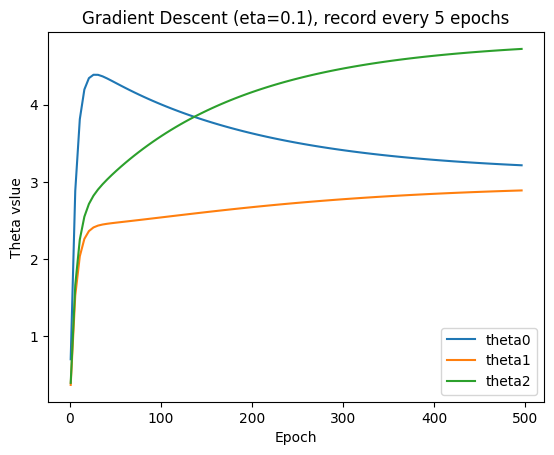

In [5]:
plt.figure()
plt.plot(epochs_list_a, thetas_a[:, 0], label="theta0")
plt.plot(epochs_list_a, thetas_a[:, 1], label="theta1")
plt.plot(epochs_list_a, thetas_a[:, 2], label="theta2")
plt.xlabel("Epoch")
plt.ylabel("Theta vslue")
plt.title("Gradient Descent (eta=0.1), record every 5 epochs")
plt.legend()
plt.show()

In [9]:
eta_b = 0.01 
epochs_b = 5000

epochs_list_b, thetas_b = gradient_descent(
    X, y,
    eta=eta_b,
    epochs=epochs_b,
    record_every=20,
    start_epoch=1
)

print("Last recorded theta (b):", thetas_b[-1])

Last recorded theta (b): [3.21399188 2.88900455 4.72202193]


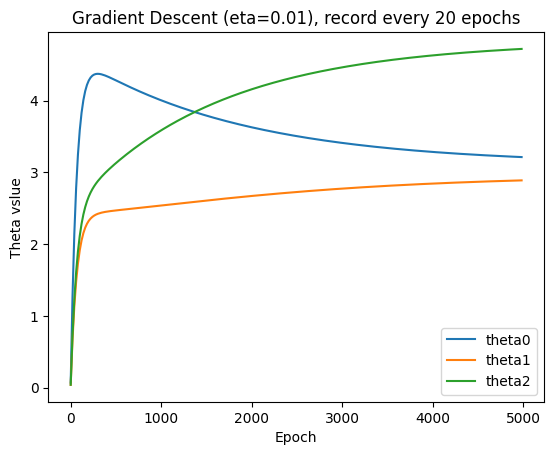

In [10]:
plt.figure()
plt.plot(epochs_list_b, thetas_b[:, 0], label="theta0")
plt.plot(epochs_list_b, thetas_b[:, 1], label="theta1")
plt.plot(epochs_list_b, thetas_b[:, 2], label="theta2")
plt.xlabel("Epoch")
plt.ylabel("Theta vslue")
plt.title("Gradient Descent (eta=0.01), record every 20 epochs")
plt.legend()
plt.show()

## 2. Stochastic Gradient Descent - learning rate (**)

Repeat task 1 but using stochastic gradient descent instead. Also adjust number of epochs to see if you can find convergence. What kind of conclusions can you draw from your experiments. (**)

---

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def sgd(X, y, eta, epochs, record_every, start_epoch=1, shuffle=True):
    m, n = X.shape
    theta = np.zeros(n)
    
    recorded_epochs = []
    recorded_thetas = []
    
    for epoch in range(1, epochs + 1):
        
        if shuffle:
            idx = np.random.permutation(m)
            X_epoch = X[idx]
            y_epoch = y[idx]
        else:
            X_epoch = X
            y_epoch = y
            
        for i in range(m):
            xi = X_epoch[i]
            yi = y_epoch[i]
            
            y_pred_i = xi @ theta
            error_i = y_pred_i - yi
            
            grad_i = xi * error_i
            theta = theta - eta * grad_i
            
        if epoch >= start_epoch and ((epoch - start_epoch) % record_every == 0):
            recorded_epochs.append(epoch)
            recorded_thetas.append(theta.copy())
        
    return np.array(recorded_epochs), np.array(recorded_thetas)

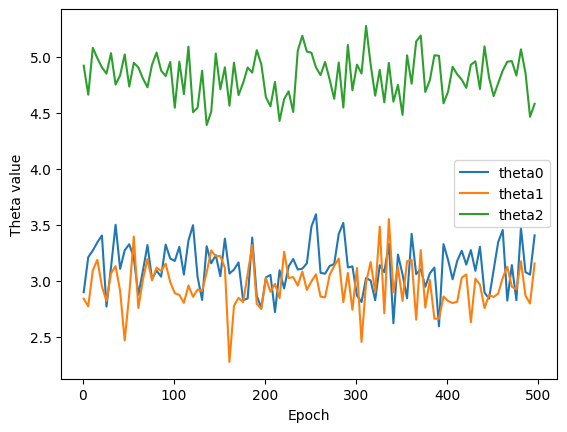

Final theta: [3.40696724 3.1563397  4.58235965]


In [16]:
epochs_sgd, thetas_sgd = sgd(X, y, eta=0.1, epochs=500, record_every=5)

plt.figure()
plt.plot(epochs_sgd, thetas_sgd[:, 0], label="theta0")
plt.plot(epochs_sgd, thetas_sgd[:, 1], label="theta1")
plt.plot(epochs_sgd, thetas_sgd[:, 2], label="theta2")
plt.xlabel("Epoch")
plt.ylabel("Theta value")
plt.legend()
plt.show()

print("Final theta:", thetas_sgd[-1])

## 3. Mini Batch Gradient Descent (**)

Now try different sizes of mini-batches and make some exploratory plots to see convergence. Also you can make comparison to the other algorithms by using same $\eta$ and same amount of epochs to see how they differ from each other in terms of convergence. (**)

In [17]:
def mini_batch_gd(X, y, eta, epochs, batch_size, record_every=5):
    m, n = X.shape
    theta = np.zeros(n)
    
    recorded_epochs = []
    recorded_thetas = []
    
    for epoch in range(1, epochs + 1):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            y_pred = X_batch @ theta
            error = y_pred - y_batch
            
            grad = (1/len(X_batch)) * (X_batch.T @ error)
            theta = theta - eta * grad
            
        if epoch % record_every == 0:
            recorded_epochs.append(epoch)
            recorded_thetas.append(theta.copy())
            
    return np.array(recorded_epochs), np.array(recorded_thetas)

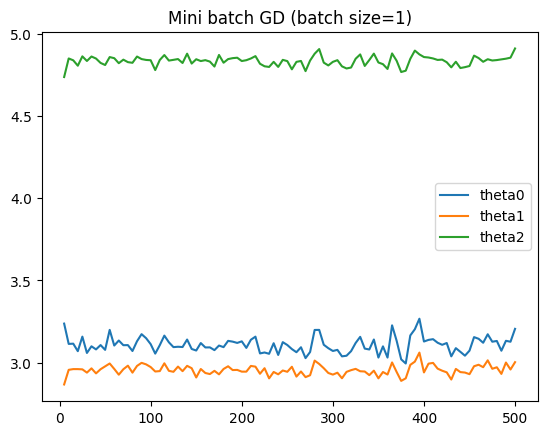

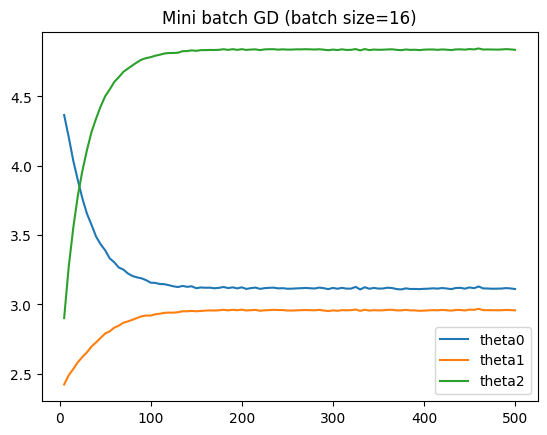

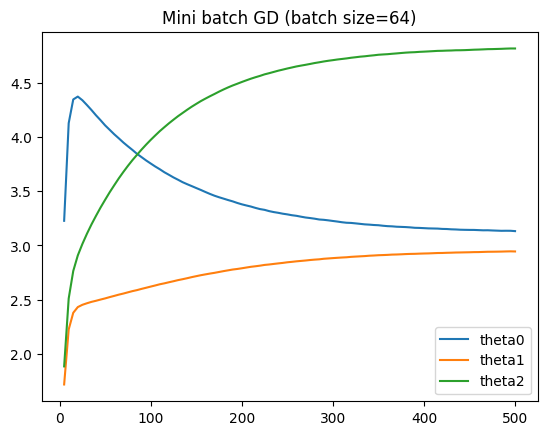

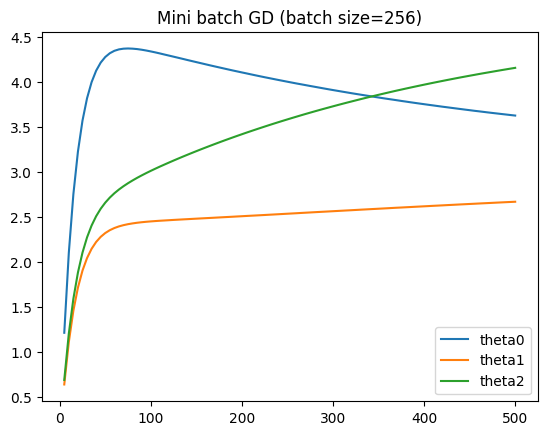

In [18]:
batch_size = [1, 16, 64, 256]

for bs in batch_size:
    epochs_mb, thetas_mb = mini_batch_gd(X, y, eta=0.01, epochs=500, batch_size=bs)
    
    plt.figure()
    plt.plot(epochs_mb, thetas_mb[:, 0], label="theta0")
    plt.plot(epochs_mb, thetas_mb[:, 1], label="theta1")
    plt.plot(epochs_mb, thetas_mb[:, 2], label="theta2")
    plt.title(f"Mini batch GD (batch size={bs})")
    plt.legend()
    plt.show()

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---